# Visualizing the BA-Shapes Dataset
This notebook loads our custom BA-Shapes dataset and visualizes the graph topology. Our goal is to verify that the Barabási-Albert base graph was generated correctly and that the 5-node "house" motifs are attached and labeled accurately:
* **Label 0:** Base Graph Node (Gray)
* **Label 1:** Top of House (Orange)
* **Label 2:** Middle of House (Blue)
* **Label 3:** Bottom of House (Green)

In [1]:
import os
import sys
import yaml
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

sys.path.append(os.path.abspath('..'))

from src.data.factory import get_dataset 

torch.manual_seed(42)

In [2]:
config_path = '../config/dataset/ba_shapes.yaml'
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

print(f"Loading dataset via factory...")
dataset = get_dataset(config)

print(f"Total Graphs Generated: {len(dataset)}")

Loading dataset via factory...
[Dataset] Found processed ba_shapes at ./data/ba_shapes/processed/ba_shapes_graph_level.pt. Loading from disk...
Total Graphs Generated: 1000


In [3]:
pos_graph_data = None
neg_graph_data = None

for data in dataset:
    if data.y.item() == 1 and pos_graph_data is None:
        pos_graph_data = data
    elif data.y.item() == 0 and neg_graph_data is None:
        neg_graph_data = data
        
    if pos_graph_data and neg_graph_data:
        break

print(f"Positive Graph (House): {pos_graph_data.num_nodes} nodes, {pos_graph_data.num_edges} edges.")
print(f"Negative Graph (No House): {neg_graph_data.num_nodes} nodes, {neg_graph_data.num_edges} edges.")

if hasattr(pos_graph_data, 'spatial_pos'):
    print(f"Graphormer spatial_pos matrix shape: {pos_graph_data.spatial_pos.shape}")

Positive Graph (House): 20 nodes, 42 edges.
Negative Graph (No House): 20 nodes, 38 edges.
Graphormer spatial_pos matrix shape: torch.Size([20, 20])


### 1. Macro-View
First, let's look at the entire graph. We use a spring layout which naturally pushes highly connected nodes (the BA core) to the center and less connected nodes (the houses) to the edges.

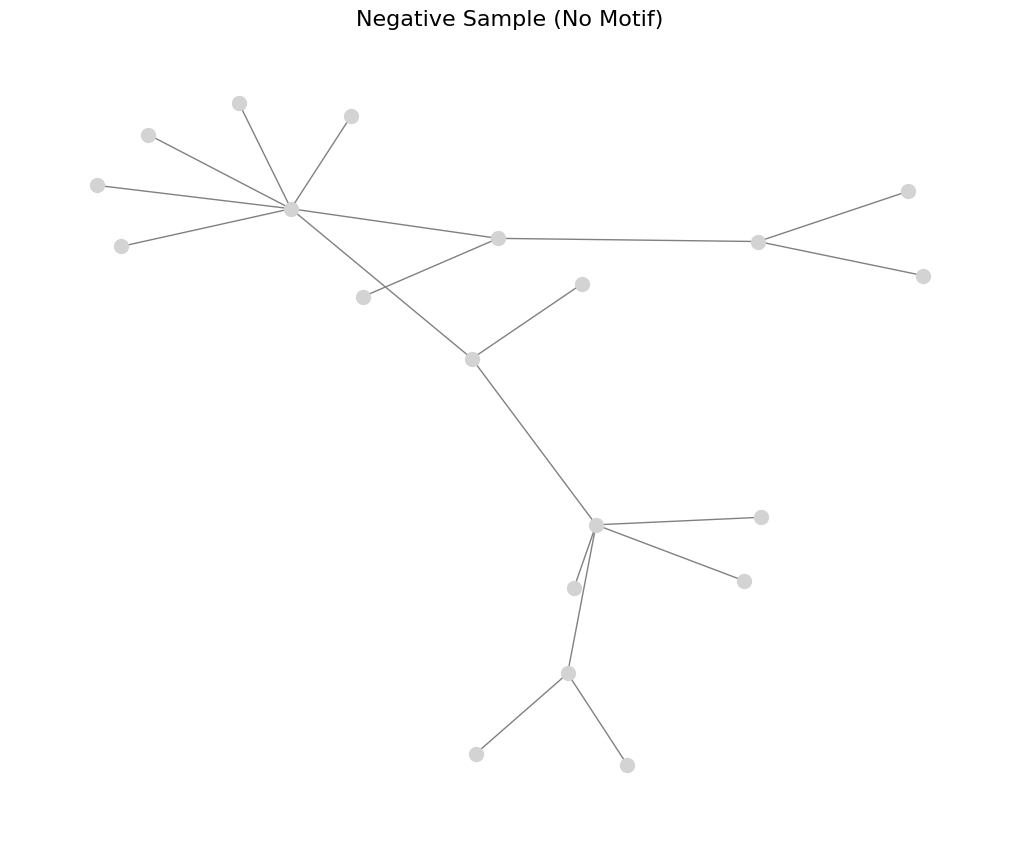

In [4]:
G_neg = to_networkx(neg_graph_data, to_undirected=True)

plt.figure(figsize=(10, 8))
pos_neg = nx.spring_layout(G_neg, seed=42)

nx.draw(
    G_neg, pos_neg, 
    node_size=100, 
    node_color='lightgray', 
    edge_color='gray',
    with_labels=False
)
plt.title("Negative Sample (No Motif)", fontsize=16)
plt.show()

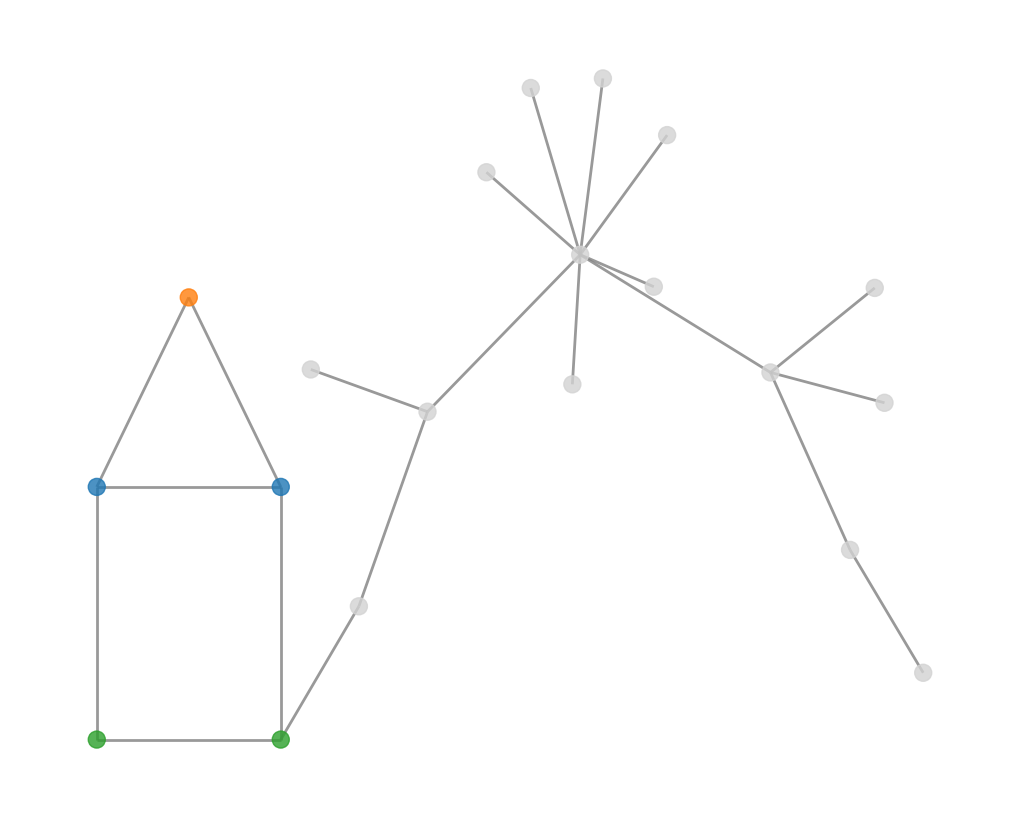

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Map your graph data
G_pos = to_networkx(pos_graph_data, to_undirected=True)
num_nodes = G_pos.number_of_nodes()

# 2. Build color assignments (Your original logic)
node_colors = []
for n in G_pos.nodes():
    if n < num_nodes - 5:
        node_colors.append('lightgray')  # Base nodes
    elif n == num_nodes - 5:
        node_colors.append('#ff7f0e')    # Top (Orange)
    elif n in [num_nodes - 4, num_nodes - 3]:
        node_colors.append('#1f77b4')    # Middle (Blue)
    else:
        node_colors.append('#2ca02c')    # Bottom (Green)

# 3. THE TRICK: Define explicit layout coordinates for the house structure
# We place it nicely near the center (0,0) of the spring layout space
house_nodes = [
    num_nodes - 5,  # Top/Roof
    num_nodes - 4,  # Middle Left
    num_nodes - 3,  # Middle Right
    num_nodes - 2,  # Bottom Left
    num_nodes - 1   # Bottom Right
]

# Initialize a manual position dictionary
pos_pos = {}

# Geometrically draw the house:
pos_pos[num_nodes - 5] = (0.0, 0.5)   # Roof tip (Orange)
pos_pos[num_nodes - 4] = (-0.2, 0.2)  # Ceiling left (Blue)
pos_pos[num_nodes - 3] = (0.2, 0.2)   # Ceiling right (Blue)
pos_pos[num_nodes - 2] = (-0.2, -0.2) # Floor left (Green)
pos_pos[num_nodes - 1] = (0.2, -0.2)  # Floor right (Green)

# 4. Let spring_layout position the REST of the random graph around our fixed house
pos_pos = nx.spring_layout(
    G_pos, 
    pos=pos_pos,          # Feed it our preset house positions
    fixed=house_nodes,    # Lock the house nodes so the simulation can't move them
    k=0.15,               # Optimal spacing parameter
    seed=42
)

# 5. Render the graph
plt.figure(figsize=(10, 8))
nx.draw(
    G_pos, 
    pos=pos_pos, 
    node_size=150, 
    node_color=node_colors, 
    edge_color='gray',
    width=2.0,
    alpha=0.8,
    with_labels=False
)

#plt.title("Positive Sample (House Motif Geometrically Locked)", fontsize=16)
plt.axis('off') # Clean layout padding
#plt.savefig('/home/nikodem/Downloads/house_motif.png', dpi=600, bbox_inches='tight')
plt.show()

Loading configuration...
Loading base dataset...
[Dataset] Found processed ba_shapes at ./data/ba_shapes/processed/ba_shapes_graph_level.pt. Loading from disk...
Loading counterfactual dataset...
[Counterfactuals] Found 1 existing chunks in ./data/ba_shapes/counterfactuals. Loading into memory...


Loading Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Loading Chunks: 100%|██████████| 1/1 [00:01<00:00,  1.02s/it]


Success. Loaded 1000 counterfactual pairs.


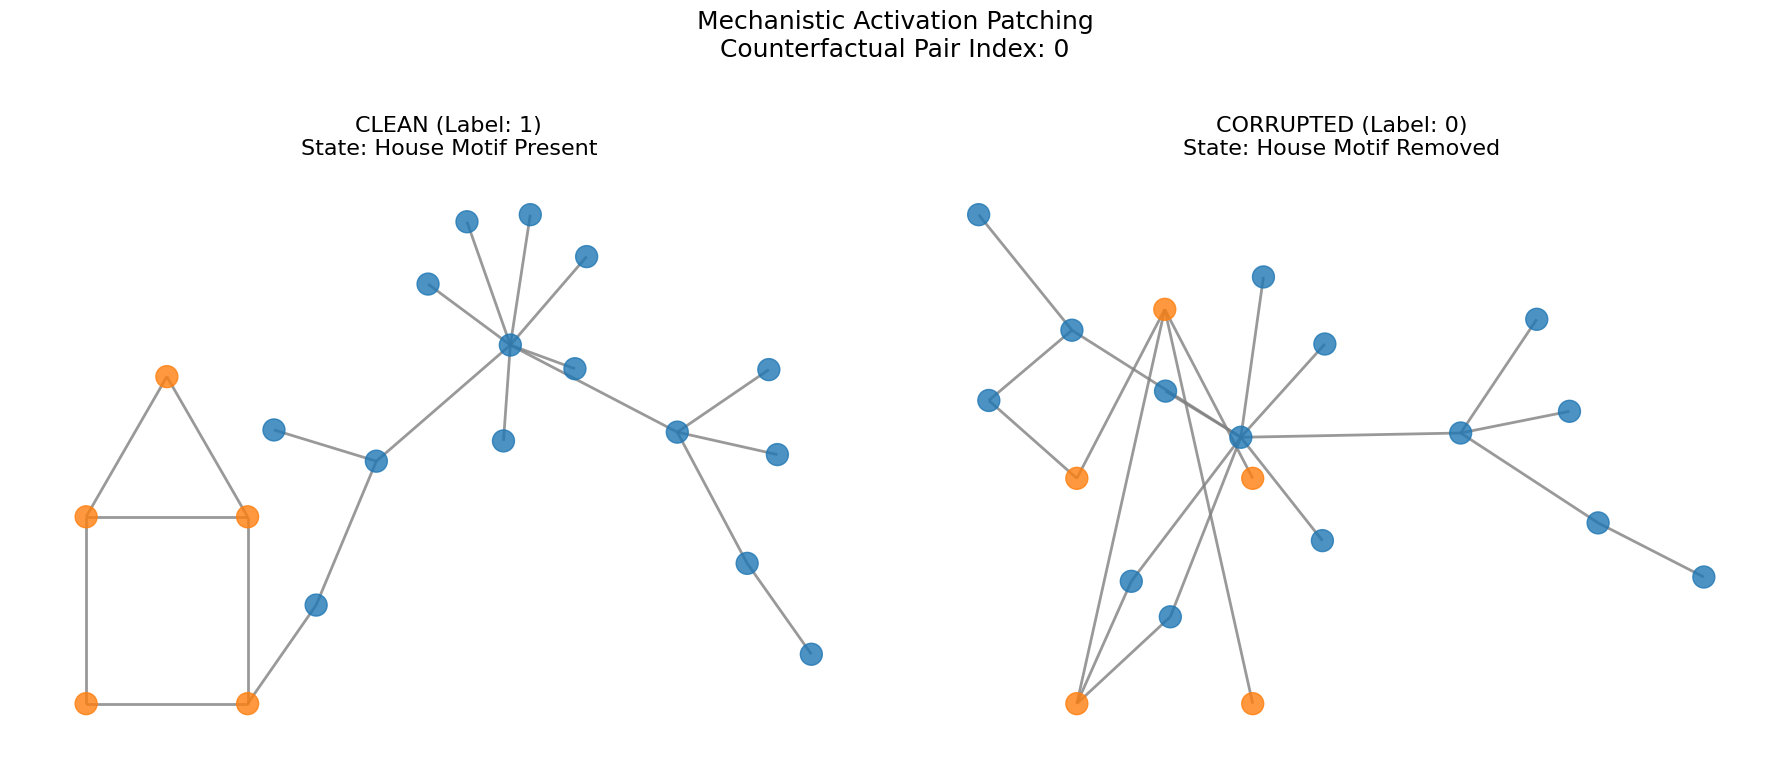

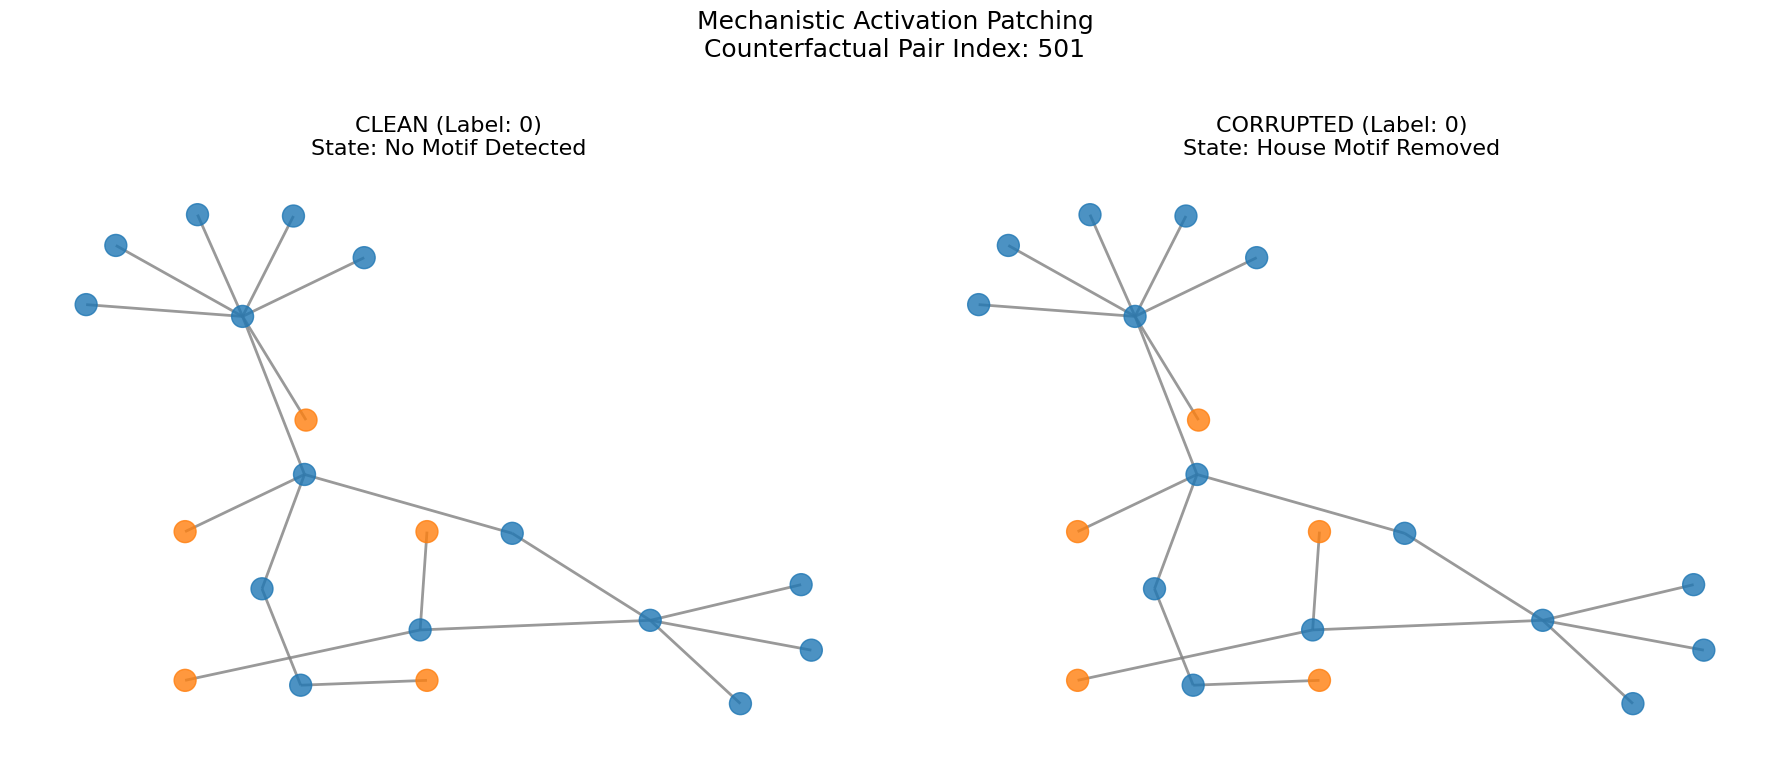

In [ ]:
import yaml
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

# Import your custom project factories
from src.data.factory import get_dataset
from src.interpretability.counterfactuals.factory import get_counterfactual_dataset

# 1. Define the path to your dataset config file here
CONFIG_PATH = "../config/dataset/ba_shapes.yaml"  # Adjust this path relative to your notebook location

# 2. Load config and fetch counterfactual pairs via the factory pipeline
print("Loading configuration...")
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

print("Loading base dataset...")
base_dataset = get_dataset(config)

print("Loading counterfactual dataset...")
# Load the counterfactual pairs directly using the factory
pairs = get_counterfactual_dataset(config, base_dataset=base_dataset)
print(f"Success. Loaded {len(pairs)} counterfactual pairs.")


# 3. Visualization function with Geometric Constraints
def plot_pair(index):
    pair = pairs[index]
    clean_data = pair['clean']
    corr_data = pair['corrupted']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # --- GEOMETRIC CONSTRAINTS & PERSISTENCE ---
    # We define the anchor points based on the Clean graph.
    # We assume (following standard BA-Shapes generation) that the Grafted Motif anchors are the *last 5 nodes* of the clean state.
    num_nodes_clean = clean_data.num_nodes
    house_node_indices = [
        num_nodes_clean - 5,  # Top/Roof
        num_nodes_clean - 4,  # Ceiling L
        num_nodes_clean - 3,  # Ceiling R
        num_nodes_clean - 2,  # Floor L
        num_nodes_clean - 1   # Floor R
    ]

    # Explicit geometric coordinates to force the house structure
    # This locked coordinate dictionary will be passed to spring_layout to override the physics engine for these specific indices.
    house_geometric_positions = {
        num_nodes_clean - 5: (0.0, 0.5),   # Top (Orange)
        num_nodes_clean - 4: (-0.2, 0.2),  # Ceiling Left
        num_nodes_clean - 3: (0.2, 0.2),   # Ceiling Right
        num_nodes_clean - 2: (-0.2, -0.2), # Floor Left
        num_nodes_clean - 1: (0.2, -0.2)   # Floor Right
    }

    # Internal function to generate consistent colors & layout constraints
    def get_constrained_visuals(data):
        G = to_networkx(data, to_undirected=True)
        colors = []
        
        # Color based purely on node indices (Persistence)
        for i in range(data.num_nodes):
            if i in house_node_indices:
                colors.append('#ff7f0e') # Highlighted Motif (Orange)
            else:
                colors.append('#1f77b4') # Base Graph Nodes (Blue)
        
        # 4. Lock the house nodes geometrically while allowing the base graph to float around them.
        pos = nx.spring_layout(
            G, 
            pos=house_geometric_positions.copy(), # Pre-seed with the house layout
            fixed=house_node_indices,           # Prevent spring_layout from moving these 5 nodes
            k=0.15,                             # Optimal spacing parameter
            seed=42                             # Maintain deterministic layout (for base nodes)
        )
        return G, colors, pos

    # --- Plot Clean Instance ---
    G_clean, colors_clean, pos_clean = get_constrained_visuals(clean_data)
    nx.draw(
        G_clean, pos_clean, 
        node_color=colors_clean, node_size=250, ax=ax1, 
        edge_color='gray', width=2.0, alpha=0.8
    )
    ax1.set_title(
        f"CLEAN (Label: {clean_data.y.item()})\n"
        f"State: {'House Motif Present' if clean_data.y == 1 else 'No Motif Detected'}", 
        fontsize=16
    )
    ax1.axis('off') # Clean visual environment

    # --- Plot Corrupted Instance (Node Persistence guaranteed here) ---
    G_corr, colors_corr, pos_corr = get_constrained_visuals(corr_data)
    nx.draw(
        G_corr, pos_corr, 
        node_color=colors_corr, node_size=250, ax=ax2, 
        edge_color='gray', width=2.0, alpha=0.8
    )
    ax2.set_title(
        f"CORRUPTED (Label: {corr_data.y.item()})\n"
        f"State: {'House Motif Added' if corr_data.y == 1 else 'House Motif Removed'}", 
        fontsize=16
    )
    ax2.axis('off') # Clean visual environment

   # plt.suptitle(f"Mechanistic Activation Patching\nCounterfactual Pair Index: {index}", fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make suptitle fit nicely
    plt.show()

# --- Test plots ---
# Test visualization for the first pair (index 0)
plot_pair(0) 

# Test visualization for a pair halfway through the dataset
plot_pair(len(pairs) // 2 + 1)